In [9]:
# import necessay libraries
import pandas as pd
import numpy  as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
data = pd.read_csv('job.csv')
data.shape

(4596, 7)

In [11]:
data.head()

,job_title,company_name,location,start_date,ctc,experience,posted
0,Business Development Associate,Break The Code,Mumbai,Starts Immediately,"₹ 2,00,000 - 3,00,000",0-1 years,3 days ago
1,IELTS/PTE/Spoken English Trainer,DePioneer Education Overseas,Delhi,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2 years,1 week ago
2,Fashion Designer,Valkyre Clothing,Mumbai,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2 years,3 days ago\n\n\nBe an early applicant
3,Corporate Sales Executive,Kompass India Information Private Limited,Mumbai,Starts Immediately,"₹ 2,00,000 - 4,00,000",0-5 years,3 weeks ago
4,Junior Python Developer,Extension Technologies Private Limited,Faridabad,Starts Immediately,"₹ 2,40,000 - 3,60,000",0-2 years,2 weeks ago


In [12]:
data.columns

Index(['job_title', 'company_name', 'location', 'start_date', 'ctc',
       'experience', 'posted'],
      dtype='object')

In [13]:
data.isnull().sum()

,0
job_title,0
company_name,0
location,0
start_date,0
ctc,0
experience,0
posted,0


In [14]:
data['job_title'].duplicated().sum()

np.int64(2829)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4596 entries, 0 to 4595
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   job_title     4596 non-null   object
 1   company_name  4596 non-null   object
 2   location      4596 non-null   object
 3   start_date    4596 non-null   object
 4   ctc           4596 non-null   object
 5   experience    4596 non-null   object
 6   posted        4596 non-null   object
dtypes: object(7)
memory usage: 251.5+ KB


In [16]:
data['ctc'].value_counts()

,count
ctc,
"₹ 2,00,000 - 3,00,000",520
"₹ 2,00,000",274
"₹ 2,00,000 - 2,50,000",249
"₹ 2,00,000 - 2,40,000",205
Competitive salary,202
...,...
"₹ 5,40,000 - 6,60,000",1
"₹ 2,80,000 - 4,00,000",1
"₹ 5,00,000 - 5,00,000",1


In [17]:
data['job_title'].value_counts()[:5]

,count
job_title,
Business Development Executive,290
Business Development Associate,129
Graphic Designer,126
Sales Executive,88
Digital Marketing Executive,73


In [18]:
data['ctc'].unique()

array(['₹ 2,00,000 - 3,00,000', '₹ 3,00,000 - 3,50,000',
       '₹ 2,00,000 - 4,00,000', '₹ 2,40,000 - 3,60,000',
       '₹ 2,40,000 - 3,00,000', '₹ 2,00,000 - 2,50,000',
       '₹ 2,52,000 - 4,00,000', '₹ 7,00,000 - 10,00,000',
       '₹ 5,00,000 - 8,00,000', '₹ 4,00,000 - 7,00,000',
       '₹ 3,00,000 - 5,00,000', '₹ 4,00,000 - 5,00,000',
       '₹ 2,00,000 - 5,00,000', '₹ 2,00,000 - 3,50,000', '₹ 2,75,000',
       '₹ 5,00,000 - 7,00,000', '₹ 3,00,000', '₹ 2,10,000 - 2,17,995',
       '₹ 5,00,000 - 10,00,000', '₹ 2,00,000 - 3,60,000', '₹ 5,00,000',
       '₹ 3,00,000 - 4,00,000', '₹ 2,50,000 - 3,00,000', '₹ 7,00,000',
       '₹ 2,50,000 - 4,75,000', '₹ 3,20,000 - 3,20,001',
       '₹ 2,20,000 - 2,60,000', '₹ 2,10,000 - 3,20,000',
       '₹ 2,60,000 - 4,00,000', '₹ 2,40,000 - 5,50,000',
       '₹ 7,00,000 - 8,00,000', '₹ 3,00,000 - 3,40,000',
       '₹ 2,80,000 - 4,50,000', '₹ 2,50,000 - 3,50,000',
       '₹ 3,75,000 - 4,00,000', '₹ 7,50,000 - 8,50,000', '₹ 4,00,000',
       '₹ 2,88,0

In [19]:
def clean_ctc(series):
    return (series
            .str.replace(r'[^0-9,]', '', regex=True)
            .str.replace(',', '', regex=False)
            .replace('', pd.NA)
           )

data['is_salary_disclosed'] = data['ctc'].ne('Competitive salary')
data['min_ctc'] = clean_ctc(data['ctc'].str.split('-').str[0])
data['max_ctc'] = clean_ctc(data['ctc'].str.split('-').str[-1])

# Optional: convert to numeric for calculations
data['min_ctc'] = pd.to_numeric(data['min_ctc'], errors='coerce')
data['max_ctc'] = pd.to_numeric(data['max_ctc'], errors='coerce')

In [20]:
data['experience'].value_counts()

,count
experience,
0-2 years,2730
0-5 years,758
1-3 years,335
0-1 years,201
4-6 years,163
0-3 years,47
7-10 years,47
1-2 years,44
1-5 years,43


In [21]:
data['experience'] = data['experience'].str.replace(' years', "")
data['min_exp'] = clean_ctc(data['experience'].str.split('-').str[0])
data['max_exp'] = clean_ctc(data['experience'].str.split('-').str[-1])

# Optional: convert to numeric for calculations
data['min_exp'] = pd.to_numeric(data['min_exp'], errors='coerce')
data['max_exp'] = pd.to_numeric(data['max_exp'], errors='coerce')

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4596 entries, 0 to 4595
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   job_title     4596 non-null   object 
 1   company_name  4596 non-null   object 
 2   location      4596 non-null   object 
 3   start_date    4596 non-null   object 
 4   ctc           4596 non-null   object 
 5   experience    4596 non-null   object 
 6   posted        4596 non-null   object 
 7   min_ctc       4388 non-null   float64
 8   max_ctc       4392 non-null   float64
 9   min_exp       4581 non-null   float64
 10  max_exp       4581 non-null   float64
dtypes: float64(4), object(7)
memory usage: 395.1+ KB


In [23]:
data[data.isna().any(axis= 1)]

,job_title,company_name,location,start_date,ctc,experience,posted,min_ctc,max_ctc,min_exp,max_exp
13,Data Analyst,Media.net,Mumbai,Starts Immediately,"₹ 4,00,000 - 5,00,000",1 year,6 days ago,400000.0,500000.0,NaN,NaN
52,3D Generalist,Studio Image Works,Gurgaon,Starts Immediately,"₹ 3,00,000 - 5,00,000",1 year,3 weeks ago,300000.0,500000.0,NaN,NaN
282,Marketing & Sales Executive,Zigsaw Consultancy,Ludhiana,Starts Immediately,"₹ 5,00,000 - 5,10,000",1 year,4 days ago\n\n\nBe an early applicant,500000.0,510000.0,NaN,NaN
325,Business Development Manager,Good Homes Kitchenware LLP,Bangalore,Starts Immediately,"₹ 5,50,000 - 6,50,000",1 year,3 days ago,550000.0,650000.0,NaN,NaN
332,Associate Recruiter,Jalan Technology Consulting,Jaipur,Starts Immediately,"₹ 2,40,000 - 3,00,000",1 year,6 days ago,240000.0,300000.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4591,PHP Developer,Unnati,Gurgaon,Starts Immediately,Competitive salary,3-5,3 weeks ago,NaN,NaN,3.0,5.0
4592,Software Developer,Unnati,Gurgaon,Starts Immediately,Competitive salary,2-10,3 weeks ago,NaN,NaN,2.0,10.0
4593,Social Media Marketing Manager,Unnati,Delhi,Starts Immediately,Competitive salary,3-4,3 weeks ago,NaN,NaN,3.0,4.0
4594,Graphic Designer,Unnati,Gurgaon,Starts Immediately,Competitive salary,3-6,3 weeks ago,NaN,NaN,3.0,6.0


## "Competitive salary" means salary is undisclosed, so we keep min_ctc and max_ctc as missing values

In [24]:
# Extract only numeric part from "1 year", "3-5", "2-10" etc.
data['min_exp'] = data['experience'].str.extract(r'(\d+)').astype(float)
data['max_exp'] = data['experience'].str.extract(r'(\d+)-?(\d+)?')[1].fillna(data['min_exp']).astype(float)

In [25]:
data[data['ctc'] == 'Competitive salary']

,job_title,company_name,location,start_date,ctc,experience,posted,min_ctc,max_ctc,min_exp,max_exp
3989,Java Developer,Leaguesol Private Limited,Hyderabad,Starts Immediately,Competitive salary,4-6,1 day ago,NaN,NaN,4.0,6.0
3990,Java Developer,Leaguesol Private Limited,Bangalore,Starts Immediately,Competitive salary,4-6,1 day ago,NaN,NaN,4.0,6.0
3995,Accountant,Freshleaf Teas,Ludhiana,Starts Immediately,Competitive salary,0-1,1 day ago,NaN,NaN,0.0,1.0
3996,Graphic Designer,Freshleaf Teas,Ludhiana,Starts Immediately,Competitive salary,0-1,1 day ago,NaN,NaN,0.0,1.0
4008,Operations Manager,R3 Consultant,Mumbai,Starts Immediately,Competitive salary,4-6,2 days ago,NaN,NaN,4.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...
4591,PHP Developer,Unnati,Gurgaon,Starts Immediately,Competitive salary,3-5,3 weeks ago,NaN,NaN,3.0,5.0
4592,Software Developer,Unnati,Gurgaon,Starts Immediately,Competitive salary,2-10,3 weeks ago,NaN,NaN,2.0,10.0
4593,Social Media Marketing Manager,Unnati,Delhi,Starts Immediately,Competitive salary,3-4,3 weeks ago,NaN,NaN,3.0,4.0
4594,Graphic Designer,Unnati,Gurgaon,Starts Immediately,Competitive salary,3-6,3 weeks ago,NaN,NaN,3.0,6.0


In [26]:
## keep undisclosed salaries as missing to avoid inventing values
data.loc[~data['is_salary_disclosed'], ['ctc', 'min_ctc', 'max_ctc']].head()

In [27]:
data.isnull().sum()

,0
job_title,0
company_name,0
location,0
start_date,0
ctc,0
experience,0
posted,0
min_ctc,0
max_ctc,0
min_exp,0


In [28]:
## convert float64 into nullable integer columns while preserving missing salaries
data['min_ctc'] = data['min_ctc'].astype('Int64')
data['max_ctc'] = data['max_ctc'].astype('Int64')
data['min_exp'] = data['min_exp'].astype('Int64')
data['max_exp'] = data['max_exp'].astype('Int64')

In [29]:
data.describe()

,min_ctc,max_ctc,min_exp,max_exp
count,4596.0,4596.0,4596.0,4596.0
mean,294720.321584,428227.586597,0.41188,2.881419
std,237383.571774,421406.019594,1.187467,1.65727
min,200000.0,1441.0,0.0,0.0
25%,200000.0,260000.0,0.0,2.0
50%,240000.0,350000.0,0.0,2.0
75%,300000.0,500000.0,0.0,4.0
max,6000000.0,11750000.0,10.0,15.0


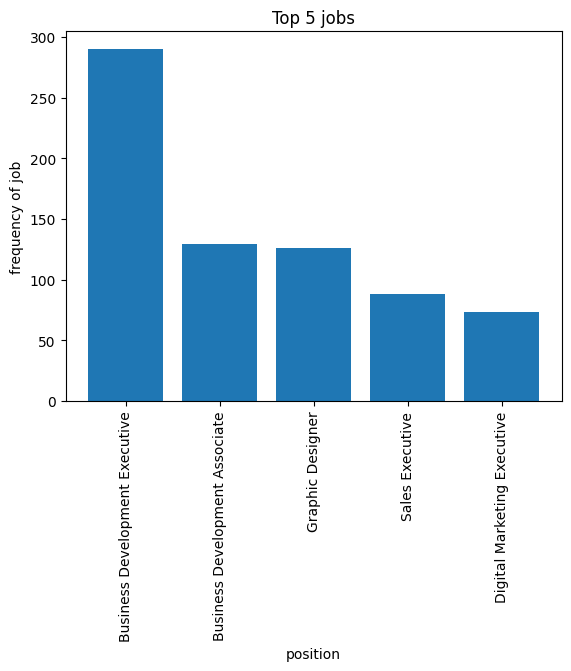

In [30]:
top_5_jobs = data['job_title'].value_counts().head(5)

plt.bar(x = top_5_jobs.index, height= top_5_jobs.values)
plt.title("Top 5 jobs")
plt.xlabel("position")
plt.ylabel("frequency of job")
plt.xticks(rotation = 90)
plt.show()

/tmp/ipykernel_1252/2418113649.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_jobs, x='job_title', y='frequency', palette='viridis')


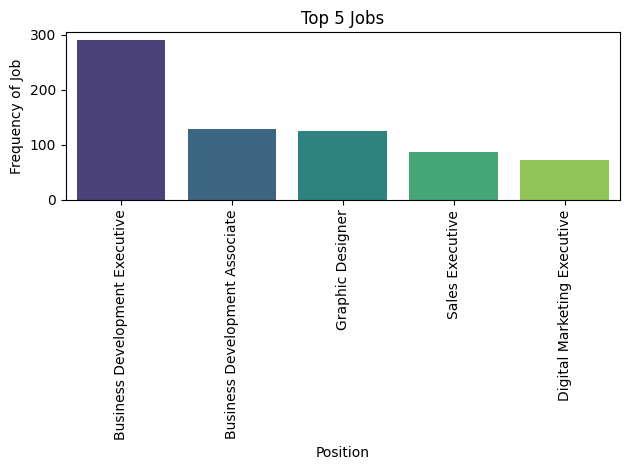

In [31]:
# instead we can use seaborn to make it more nice
import seaborn as sns

top_5_jobs = data['job_title'].value_counts().head(5).reset_index()
top_5_jobs.columns = ['job_title', 'frequency']

sns.barplot(data=top_5_jobs, x='job_title', y='frequency', palette='viridis')
plt.title("Top 5 Jobs")
plt.xlabel("Position")
plt.ylabel("Frequency of Job")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [32]:
data['posted'].unique()

array(['3 days ago', '1 week ago',
       '3 days ago\n\n\nBe an early applicant', '3 weeks ago',
       '2 weeks ago', '1 day ago\n\n\nBe an early applicant',
       '4 days ago', '2 days ago', '6 days ago', 'Few hours ago', 'Today',
       '1 day ago', '5 days ago', 'Just now\n\n\nBe an early applicant',
       'Few hours ago\n\n\nBe an early applicant',
       'Today\n\n\nBe an early applicant',
       '2 days ago\n\n\nBe an early applicant',
       '5 days ago\n\n\nBe an early applicant',
       '4 days ago\n\n\nBe an early applicant',
       '6 days ago\n\n\nBe an early applicant',
       '7 days ago\n\n\nBe an early applicant',
       '1 week ago\n\n\nBe an early applicant', '7 days ago',
       '3 weeks ago\n\n\nBe an early applicant',
       '2 weeks ago\n\n\nBe an early applicant', 'Just now'], dtype=object)

In [33]:
data['posted'] = data["posted"].str.replace("\n\n\nBe an early applicant", "")
data['posted'].unique()

array(['3 days ago', '1 week ago', '3 weeks ago', '2 weeks ago',
       '1 day ago', '4 days ago', '2 days ago', '6 days ago',
       'Few hours ago', 'Today', '5 days ago', 'Just now', '7 days ago'],
      dtype=object)

In [34]:
listing_key = ['job_title', 'company_name', 'location']

exact_duplicate_mask = data.duplicated(keep='first')
repeated_listing_mask = data.duplicated(subset=listing_key, keep=False)
repost_candidate_mask = repeated_listing_mask & ~data.duplicated(keep=False)

data['is_noisy_duplicate'] = exact_duplicate_mask
data['is_repost_candidate'] = repost_candidate_mask

print(f"Exact duplicate rows to drop from summary stats: {data['is_noisy_duplicate'].sum()}")
print(f"Rows that look like reposted/refreshed listings: {data['is_repost_candidate'].sum()}")

Exact duplicate rows: 95
Rows involved in duplicate job listings: 326


In [35]:
data.loc[data['is_noisy_duplicate'], ['job_title', 'company_name', 'location', 'ctc', 'experience', 'posted']].head(10)

,job_title,company_name,location,start_date,ctc,experience,posted,min_ctc,max_ctc,min_exp,max_exp
97,Business Development Executive,Plada Infotech Services Limited,"Noida, Gurgaon, Delhi",Starts Immediately,"₹ 2,00,000 - 4,00,000",0-2,1 week ago,200000,400000,0,2
483,Back Office Executive,Suprem Service,Work from home,Starts Immediately,"₹ 4,00,000 - 7,00,000",0-1,1 day ago,400000,700000,0,1
542,Business Development Associate,Break The Code,Mumbai,Starts Immediately,"₹ 2,00,000 - 3,00,000",0-1,3 days ago,200000,300000,0,1
772,Corporate Sales Executive,Kompass India Information Private Limited,Mumbai,Starts Immediately,"₹ 2,00,000 - 4,00,000",0-5,3 weeks ago,200000,400000,0,5
929,Customer Acquisition Executive,Sutra Services Private Limited,Mumbai,Starts Immediately,"₹ 2,00,000 - 3,50,000",0-2,3 weeks ago,200000,350000,0,2
942,Business Development Executive,Saroj Education Group,Delhi,Starts Immediately,"₹ 2,00,000 - 4,00,000",0-2,3 weeks ago,200000,400000,0,2
1300,Fashion Designer,Valkyre Clothing,Mumbai,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2,3 days ago,300000,350000,0,2
1341,IELTS/PTE/Spoken English Trainer,DePioneer Education Overseas,Delhi,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2,1 week ago,300000,350000,0,2
1446,Operations Executive,RoaDo,Bangalore,Starts Immediately,"₹ 2,50,000 - 3,50,000",0-2,2 days ago,250000,350000,0,2
1944,Video Editor & Graphic Designer,Brilliance Academy,Work from home,Starts Immediately,"₹ 2,40,000 - 3,00,000",0-2,1 week ago,240000,300000,0,2


In [36]:
repost_candidates = (data.loc[data['is_repost_candidate']]
    .sort_values(listing_key + ['posted'])
    [['job_title', 'company_name', 'location', 'ctc', 'experience', 'posted']]
)

repost_candidates.head(10)

,job_title,company_name,location,ctc,experience,posted
679,Accountant,A1 Advance,Work from home,"₹ 4,00,000 - 7,00,000",0,1 week ago
2388,Accountant,A1 Advance,Work from home,"₹ 5,00,000 - 7,00,000",0-5,1 week ago
4250,Accountant,Aline HR Consultancy,Mumbai,"₹ 2,64,000 - 3,00,000",1-3,2 weeks ago
4294,Accountant,Aline HR Consultancy,Mumbai,"₹ 2,64,000 - 3,00,000",1-3,3 weeks ago
4046,Accountant,Gamut HR Solutions,Hyderabad,"₹ 3,00,000 - 3,24,000",4-6,6 days ago


In [44]:
analysis_data = data.loc[~data['is_noisy_duplicate']].copy()
print(f'Rows in original data: {len(data)}')
print(f'Rows used for summary stats: {len(analysis_data)}')
analysis_data.head()

,job_title,company_name,location,start_date,ctc,experience,posted,min_ctc,max_ctc,min_exp,max_exp
0,Business Development Associate,Break The Code,Mumbai,Starts Immediately,"₹ 2,00,000 - 3,00,000",0-1,3 days ago,200000,300000,0,1
1,IELTS/PTE/Spoken English Trainer,DePioneer Education Overseas,Delhi,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2,1 week ago,300000,350000,0,2
2,Fashion Designer,Valkyre Clothing,Mumbai,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2,3 days ago,300000,350000,0,2
3,Corporate Sales Executive,Kompass India Information Private Limited,Mumbai,Starts Immediately,"₹ 2,00,000 - 4,00,000",0-5,3 weeks ago,200000,400000,0,5
4,Junior Python Developer,Extension Technologies Private Limited,Faridabad,Starts Immediately,"₹ 2,40,000 - 3,60,000",0-2,2 weeks ago,240000,360000,0,2


In [47]:
def convert_to_days(posted):
    if pd.isna(posted):
        return pd.NA
    posted = str(posted).strip()
    if posted in ['Just now', 'Few hours ago', 'Today'] or 'hour' in posted:
        return 0
    if 'week' in posted:
        return int(posted.split()[0]) * 7
    if 'day' in posted:
        return int(posted.split()[0])
    return pd.NA

analysis_data['posted_days'] = analysis_data['posted'].apply(convert_to_days).astype('Int64')
analysis_data['is_remote'] = analysis_data['location'].str.contains('Work from home', case=False, na=False)
analysis_data['avg_ctc'] = ((analysis_data['min_ctc'] + analysis_data['max_ctc']) / 2).round(0).astype('Int64')

analysis_data[['posted', 'posted_days', 'is_remote', 'avg_ctc']].head()

In [61]:
analysis_data[['posted_days', 'is_remote', 'avg_ctc']].describe(include='all')

In [64]:
top_10_jobs = analysis_data['job_title'].value_counts().head(10).reset_index()
top_10_jobs.columns = ['job_title', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_jobs, x='count', y='job_title', hue='job_title', palette='viridis', legend=False)
plt.title('Top 10 Job Titles')
plt.xlabel('Number of Listings')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

,job_title,company_name,location,start_date,ctc,experience,posted,min_ctc,max_ctc,min_exp,max_exp
0,Business Development Associate,Break The Code,Mumbai,Starts Immediately,"₹ 2,00,000 - 3,00,000",0-1,3,200000,300000,0,1
1,IELTS/PTE/Spoken English Trainer,DePioneer Education Overseas,Delhi,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2,7,300000,350000,0,2
2,Fashion Designer,Valkyre Clothing,Mumbai,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2,3,300000,350000,0,2
3,Corporate Sales Executive,Kompass India Information Private Limited,Mumbai,Starts Immediately,"₹ 2,00,000 - 4,00,000",0-5,21,200000,400000,0,5
4,Junior Python Developer,Extension Technologies Private Limited,Faridabad,Starts Immediately,"₹ 2,40,000 - 3,60,000",0-2,14,240000,360000,0,2
...,...,...,...,...,...,...,...,...,...,...,...
4591,PHP Developer,Unnati,Gurgaon,Starts Immediately,Competitive salary,3-5,21,240000,350000,3,5
4592,Software Developer,Unnati,Gurgaon,Starts Immediately,Competitive salary,2-10,21,240000,350000,2,10
4593,Social Media Marketing Manager,Unnati,Delhi,Starts Immediately,Competitive salary,3-4,21,240000,350000,3,4
4594,Graphic Designer,Unnati,Gurgaon,Starts Immediately,Competitive salary,3-6,21,240000,350000,3,6


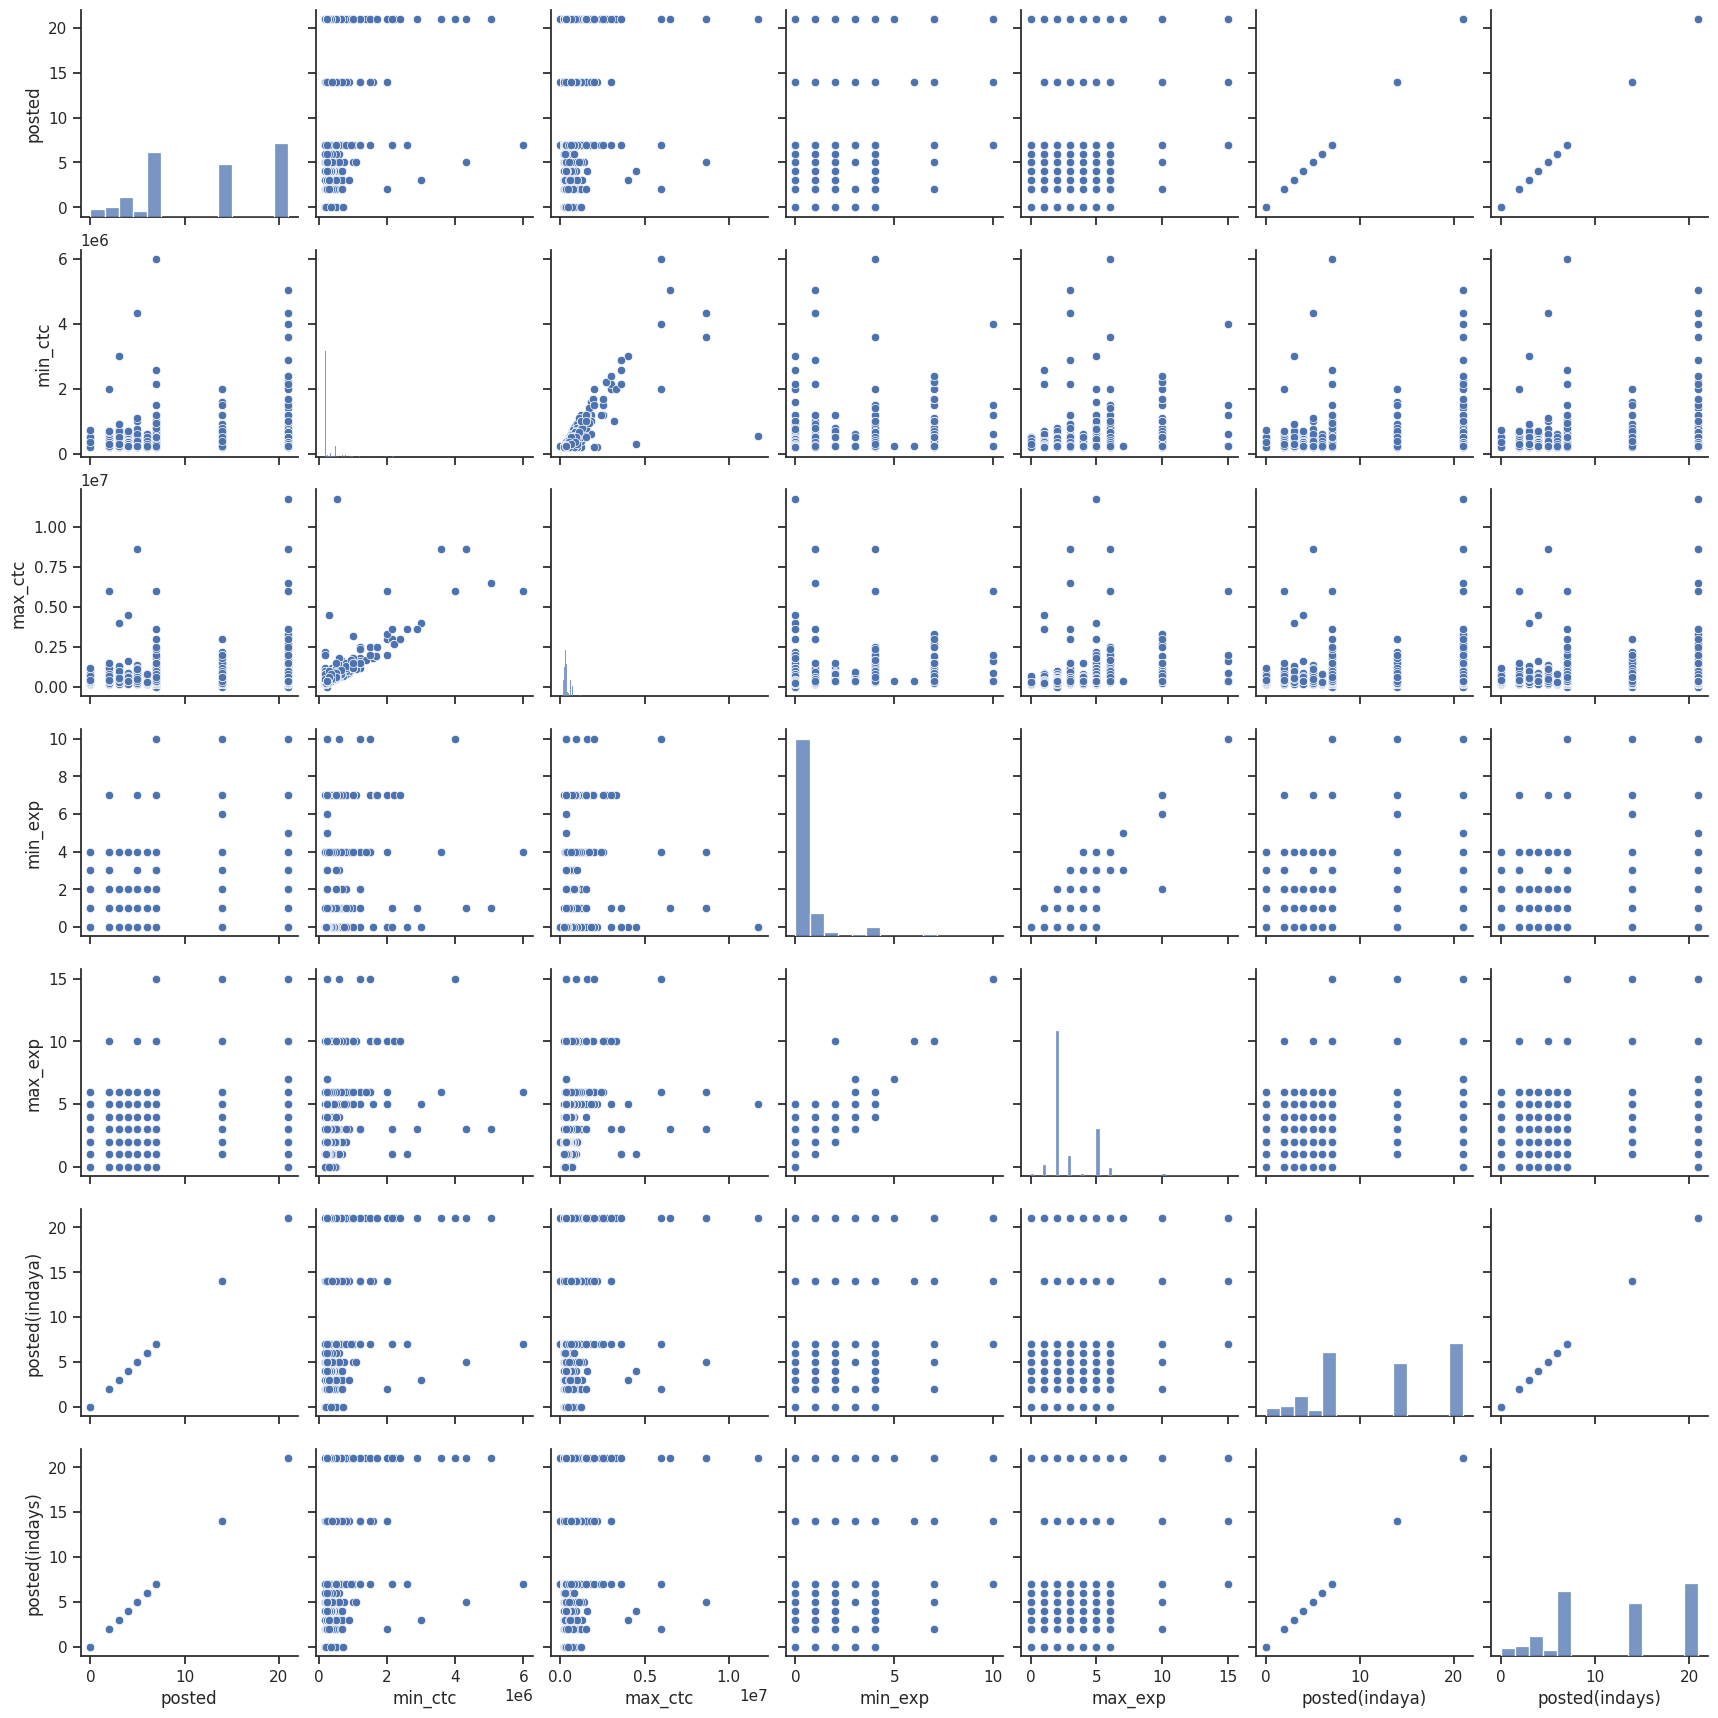

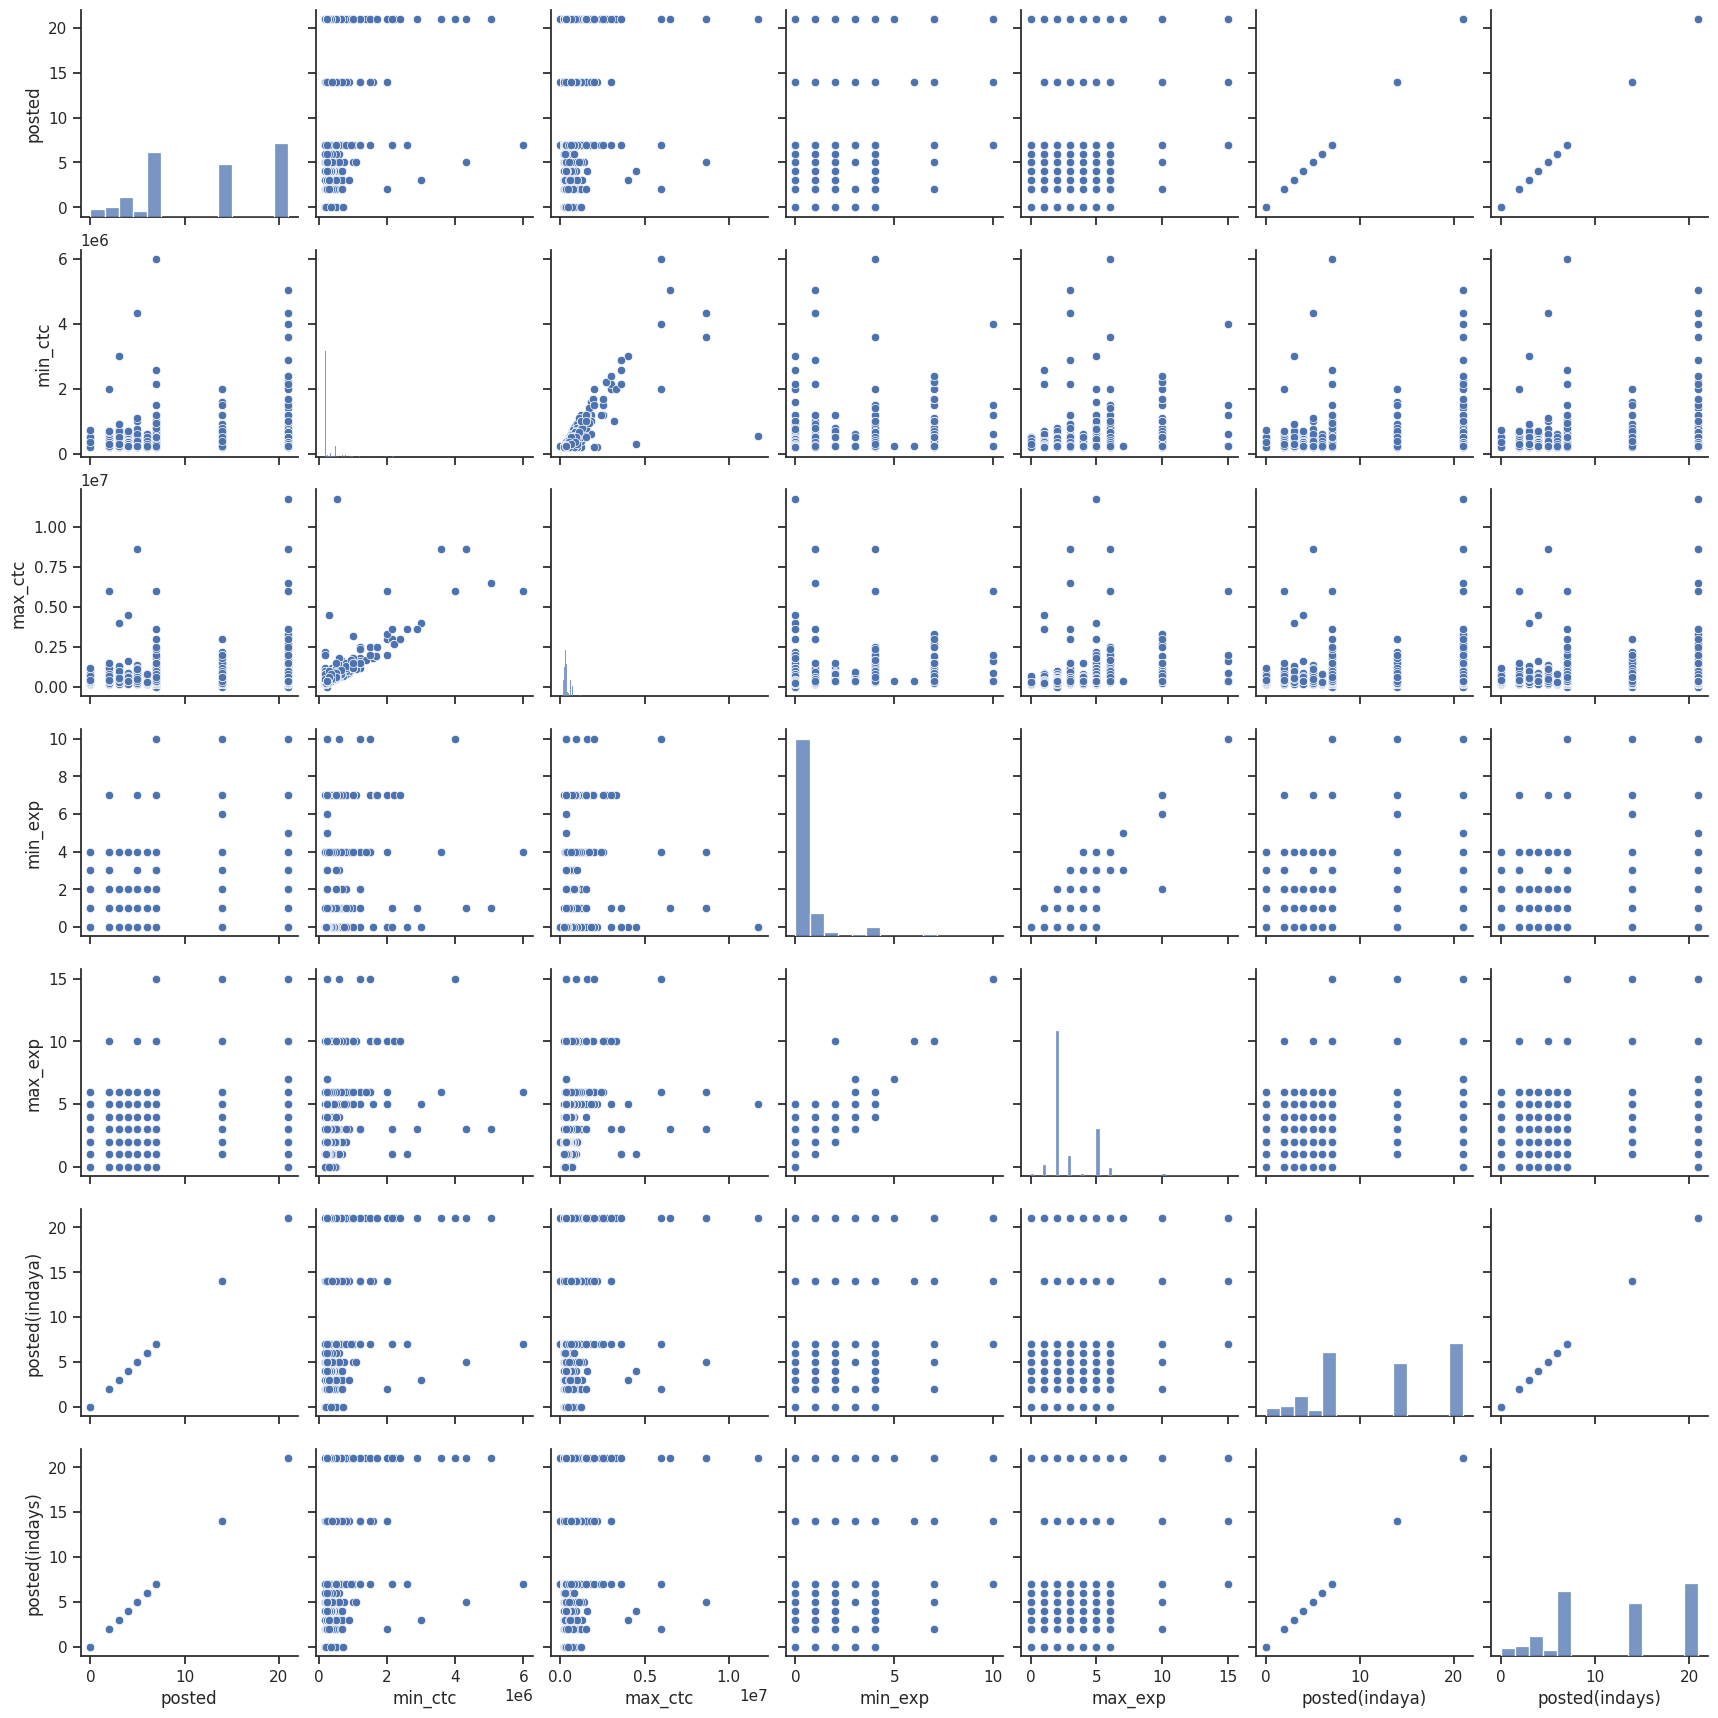

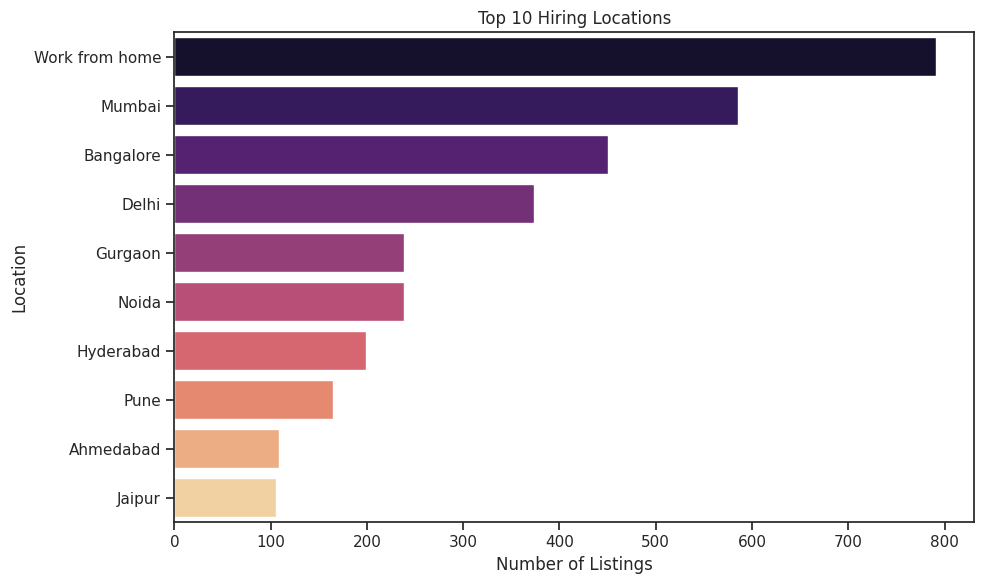

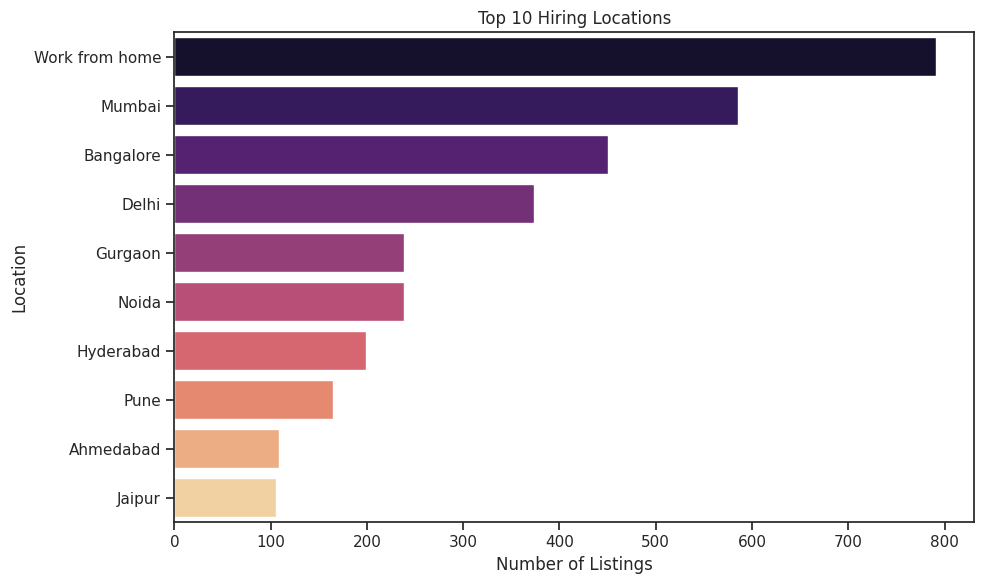

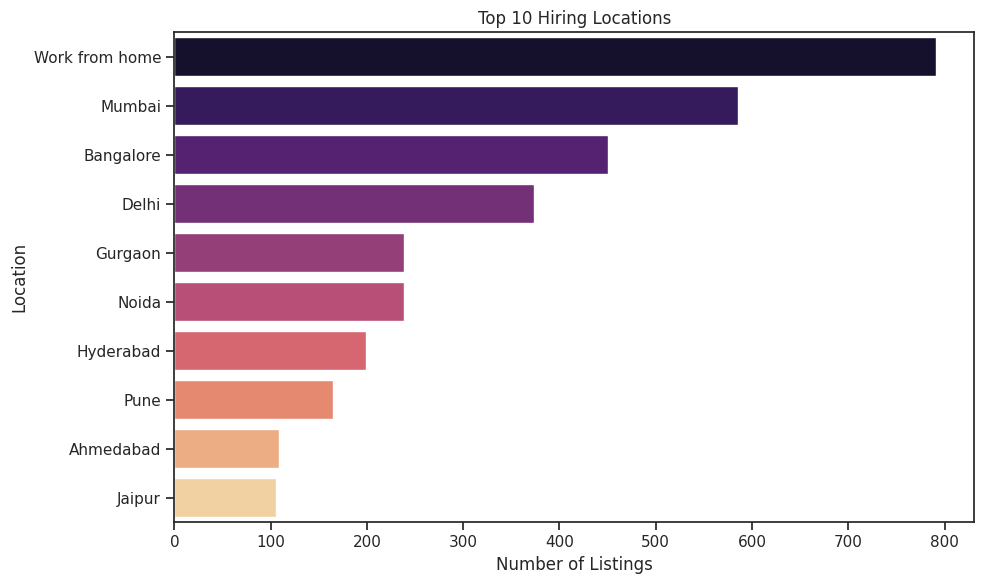

In [76]:
%matplotlib inline
import matplotlib.pyplot as plt
top_10_locations = data['location'].value_counts().head(10).reset_index()
top_10_locations.columns = ['location', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_locations, x='count', y='location', hue='location', palette='magma', legend=False)
plt.title('Top 10 Hiring Locations')
plt.xlabel('Number of Listings')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

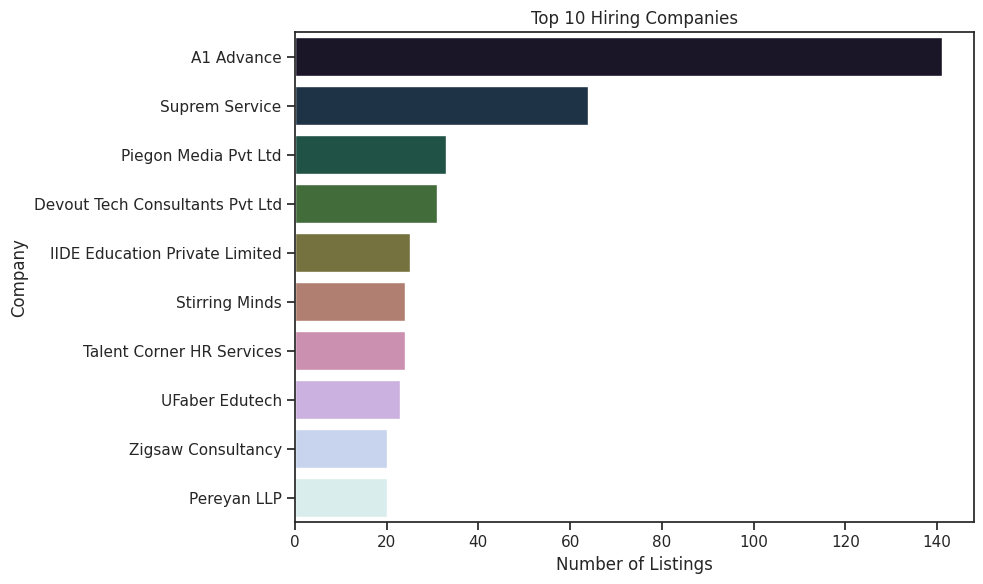

In [78]:
top_10_companies = data['company_name'].value_counts().head(10).reset_index()
top_10_companies.columns = ['company_name', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_companies, x='count', y='company_name', hue='company_name', palette='cubehelix', legend=False)
plt.title('Top 10 Hiring Companies')
plt.xlabel('Number of Listings')
plt.ylabel('Company')
plt.tight_layout()
plt.show()